# NN draw

In [1]:
import jax
import numpy as np
import pandas as pd
from time import time
import seaborn as sns
import jax.numpy as jnp
import flax.linen as nn
import matplotlib.pyplot as plt
from functools import partial
from jaxopt import ProjectedGradient

In [3]:
from bayesopt import test_functions, eval_fn, agents
from methods import low_rank_last_layer as lrll

In [4]:
%config InlineBackend.figure_format = "retina"
%load_ext autoreload
%autoreload 2

In [5]:
# plt.rc("text", usetex=True)
sns.set_palette("colorblind")
# plt.rcParams["figure.figsize"] = (7.2, 4.2 * 0.6)
plt.rcParams["figure.figsize"] = (7.2, 4.2)
colors = sns.color_palette()

In [6]:
def plot_hist(ax, runs, color=None, **kwargs):
    steps = np.arange(len(runs[0]))
    med_run = np.quantile(runs, 0.5, axis=0)
    
    lbound = np.quantile(runs, 0.25, axis=0)
    ubound = np.quantile(runs, 0.75, axis=0)

    color_plot = "black" if color is None else color
    color_fill = "tab:gray" if color is None else color
    
    ax.plot(med_run, c=color_plot, **kwargs)
    ax.fill_between(steps, lbound, ubound, color=color_fill, alpha=0.3)

# Setup

In [7]:
key = jax.random.PRNGKey(3141)
key_init, key_run = jax.random.split(key)

In [8]:
n_runs = 10
keys = jax.random.split(key_run, n_runs)

In [9]:
n_steps = 600
dim = 200
query_method = "grad"
exploration_method = "thompson_sampling"

In [10]:
rank = 50
X_init = jnp.ones((1, dim))
objective_fn = test_functions.init_fn_draw_nn(key_init, dim)

In [11]:
lbound, ubound = 0.0, 1.0
n_warmup = dim

# Fifo Laplace

In [12]:
%%time
agent, bel_init_fn = agents.load_ll_laplace_agent(
    X_init, learning_rate=1e-4, buffer_size=10, n_inner=50,
    noise=0.1
)

time_init = time()
runs_laplace_diag = eval_fn.test_runs(
    keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, n_warmup, query_method,
    exploration_method
)
runs_laplace_diag = jax.tree.map(np.array, runs_laplace_diag)
time_laplace = time() - time_init

CPU times: user 31 s, sys: 1.23 s, total: 32.2 s
Wall time: 26 s


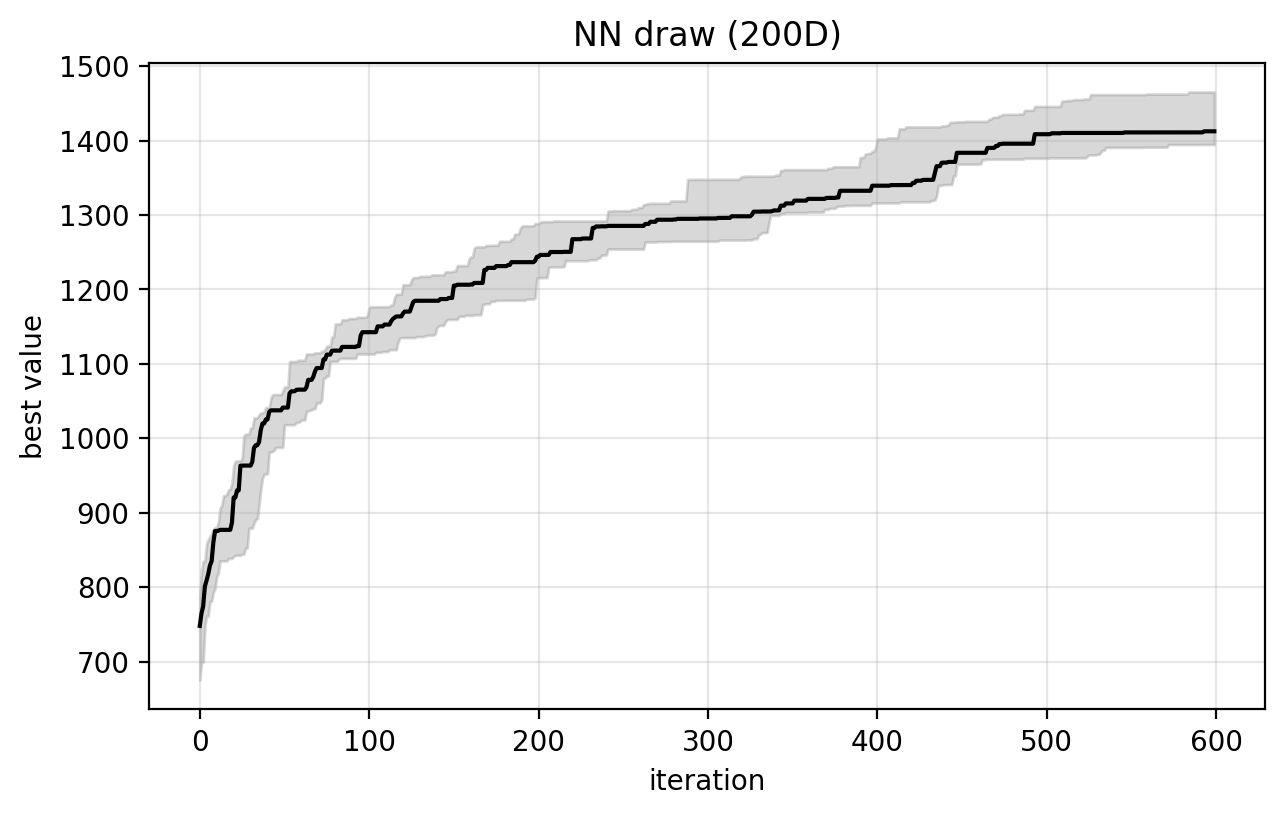

In [13]:
fig, ax = plt.subplots()
plot_hist(ax, runs_laplace_diag["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

## LL-LRKF: FLoRES

In [14]:
agent, bel_init_fn = agents.load_ll_lrkf_agent(
    X_init, rank=rank, cov_hidden=1e-4, cov_last=1.0, low_rank_diag=True,
    dynamics_last=0.0, dynamics_hidden=0.0, obs_noise=0.0
)

In [15]:
%%time
time_init = time()
runs_flores = eval_fn.test_runs(
    keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, n_warmup,
    query_method, exploration_method
)
runs_flores = jax.tree.map(np.array, runs_flores)
time_flores = time() - time_init

CPU times: user 28.3 s, sys: 313 ms, total: 28.6 s
Wall time: 24.5 s


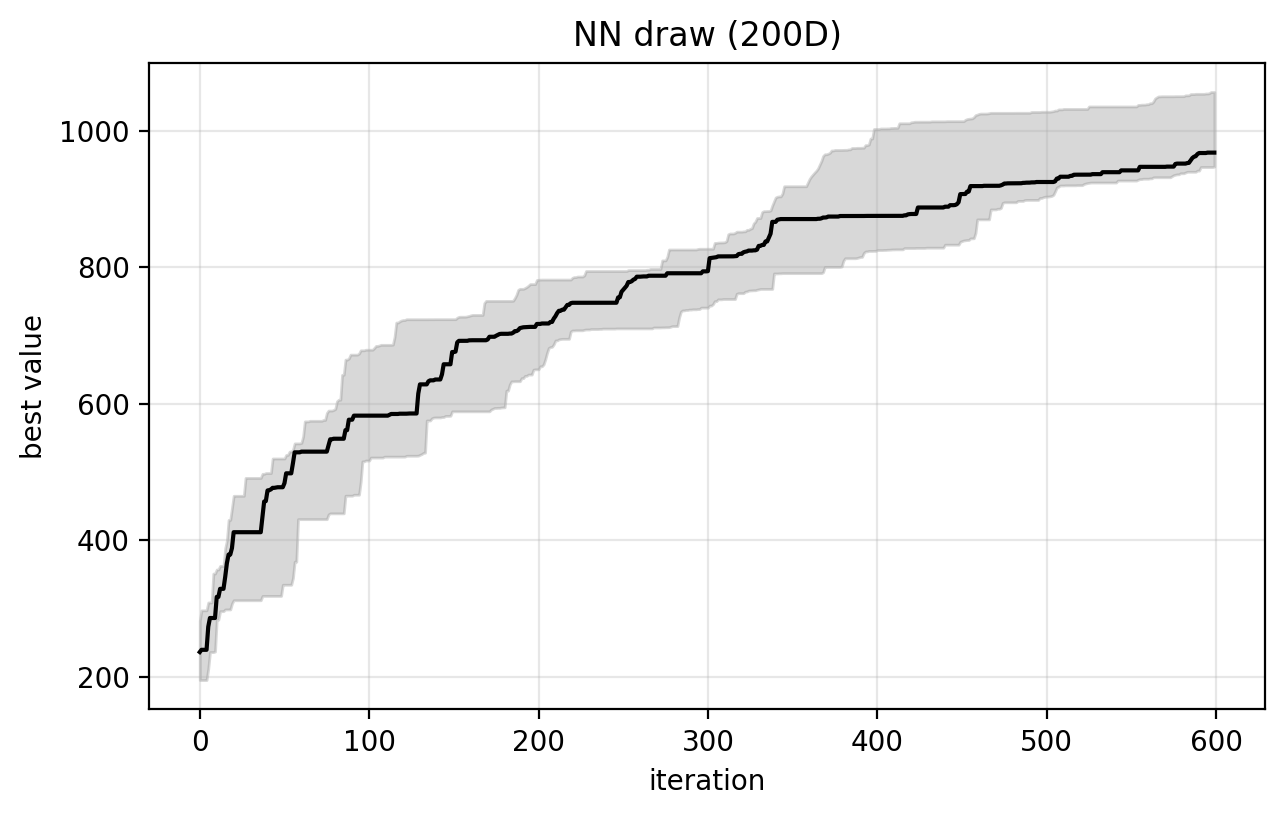

In [16]:
fig, ax = plt.subplots()
plot_hist(ax, runs_flores["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

# LRKF

In [17]:
agent, bel_init_fn = agents.load_lrkf_agent(
    X_init, rank=rank, cov=1.0, obs_noise=0.0, dynamics_cov=1e-6, low_rank_diag=False,
)

In [18]:
%%time
time_init = time()
runs_lrkf = eval_fn.test_runs(
    keys[:2], n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, n_warmup,
    query_method, exploration_method
)
runs_lrkf = jax.tree.map(np.array, runs_lrkf)
time_lrkf = time() - time_init

CPU times: user 19.9 s, sys: 563 ms, total: 20.5 s
Wall time: 17.4 s


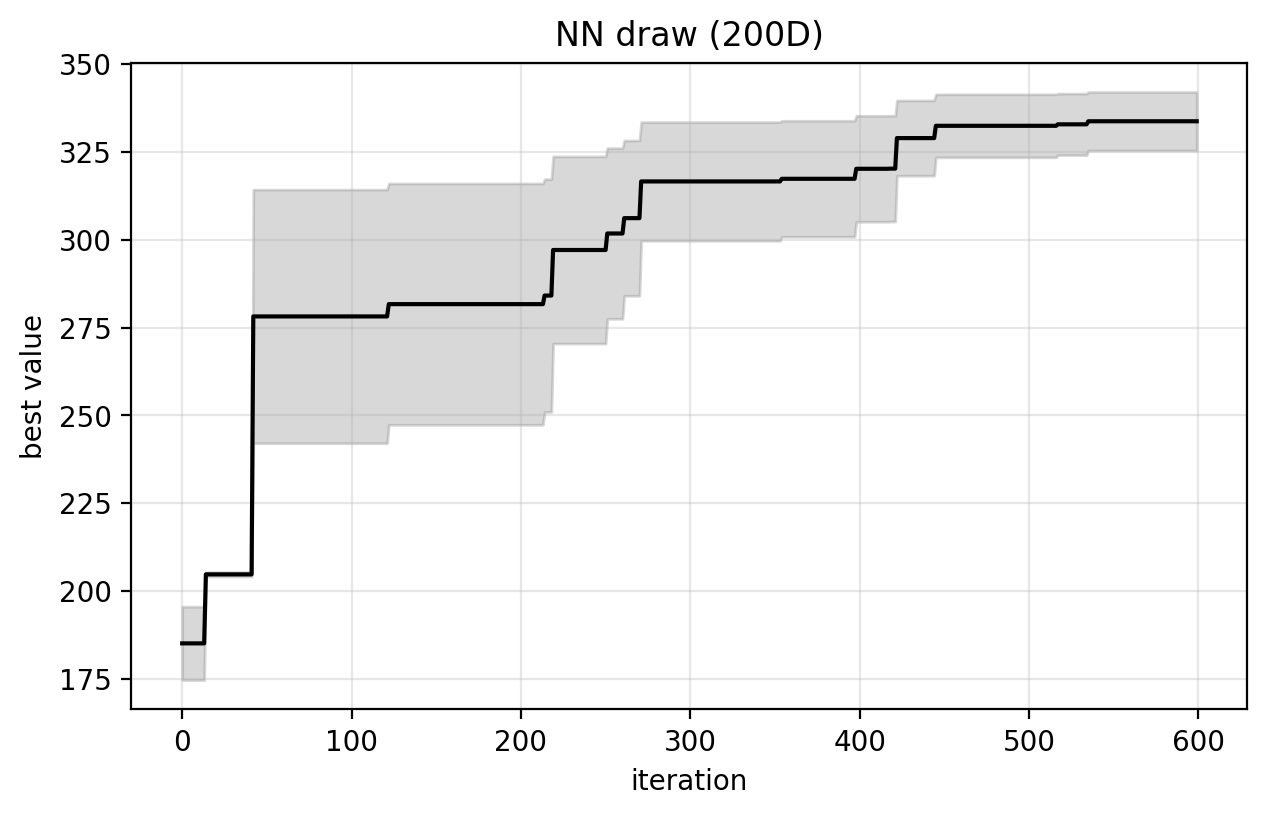

In [19]:
fig, ax = plt.subplots()
plot_hist(ax, runs_lrkf["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

## VBLL

In [20]:
agent, bel_init_fn = agents.load_fifo_vbll_agent(
    X_init, learning_rate=1e-4, buffer_size=100, n_inner=100,
    wishart_scale=0.01, regularization_weight=0.1
)

In [21]:
%%time
time_init = time()
runs_vbll_full = eval_fn.test_runs(
    keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim, query_method,
    exploration_method
)
runs_vbll_full = jax.tree.map(np.array, runs_vbll_full)
time_vbll_full = time() - time_init

CPU times: user 17.4 s, sys: 331 ms, total: 17.7 s
Wall time: 26.3 s


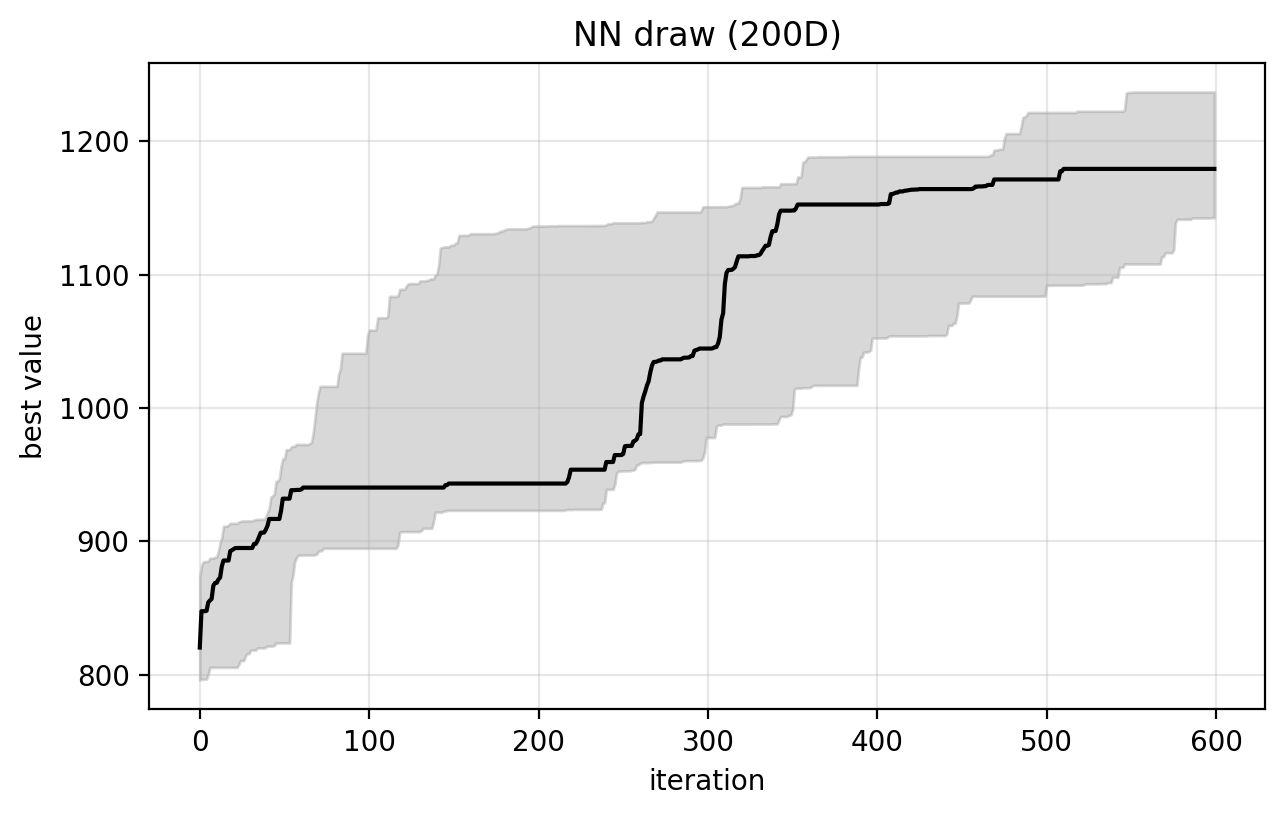

In [22]:
fig, ax = plt.subplots()
plot_hist(ax, runs_vbll_full["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

## on-VBLL

In [23]:
agent, bel_init_fn = agents.load_fifo_vbll_agent(
    X_init, learning_rate=1e-4, buffer_size=10, n_inner=rank,
    wishart_scale=0.1, regularization_weight=0.0
)

In [24]:
%%time
time_init = time()
runs_vbll = eval_fn.test_runs(
    keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim,
    query_method, exploration_method
)
runs_vbll = jax.tree.map(np.array, runs_vbll)
time_vbll = time() - time_init

CPU times: user 12.3 s, sys: 415 ms, total: 12.7 s
Wall time: 18.1 s


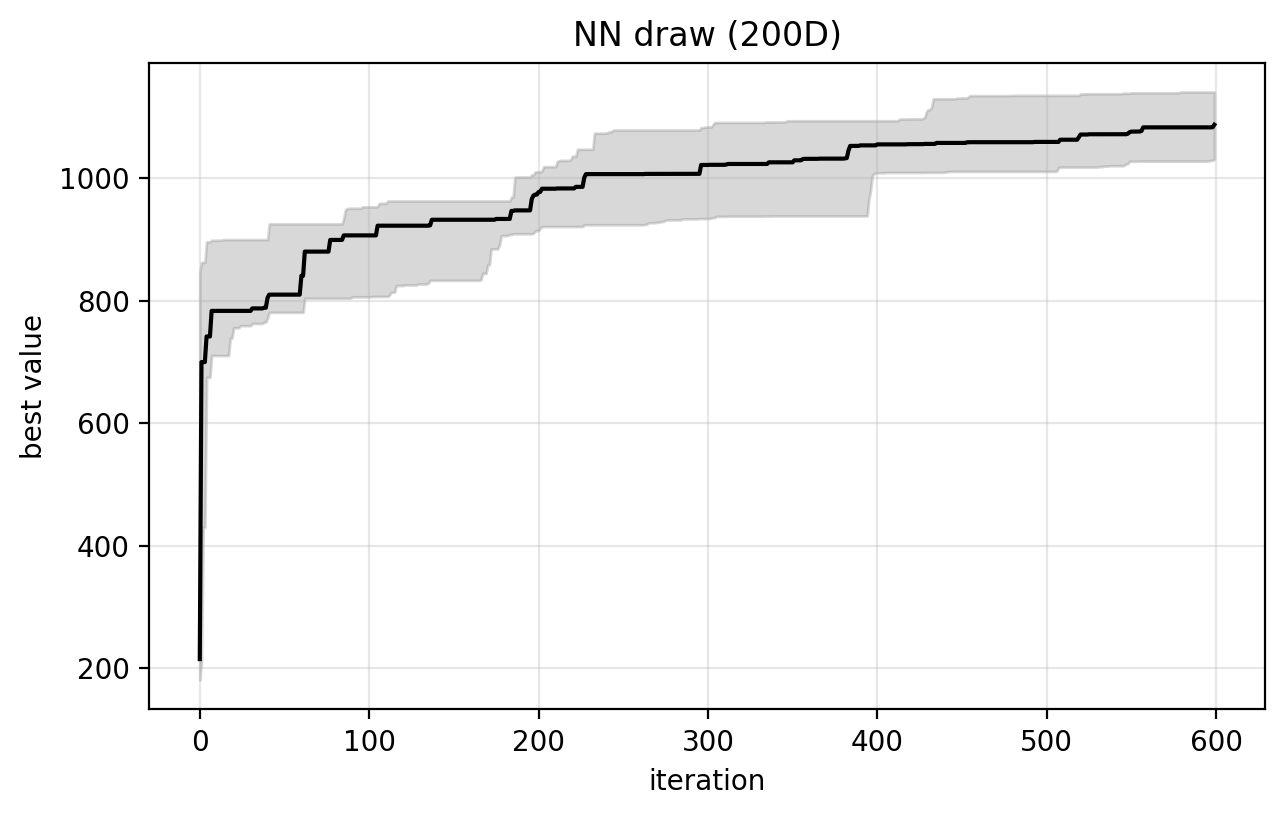

In [25]:
fig, ax = plt.subplots()
plot_hist(ax, runs_vbll["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

## LoFi

In [26]:
rank = rank
agent, bel_init_fn = agents.load_lofi_agent(
    X_init, rank=rank, cov_init=1e-6, obs_noise=2.0, dynamics_covariance=1e-6
)

In [27]:
%%time
time_init = time()
runs_lofi = eval_fn.test_runs(
    keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim,
    query_method, exploration_method,
)
runs_lofi = jax.tree.map(np.array, runs_lofi)
time_lofi = time() - time_init

CPU times: user 44.6 s, sys: 1.55 s, total: 46.2 s
Wall time: 1min 36s


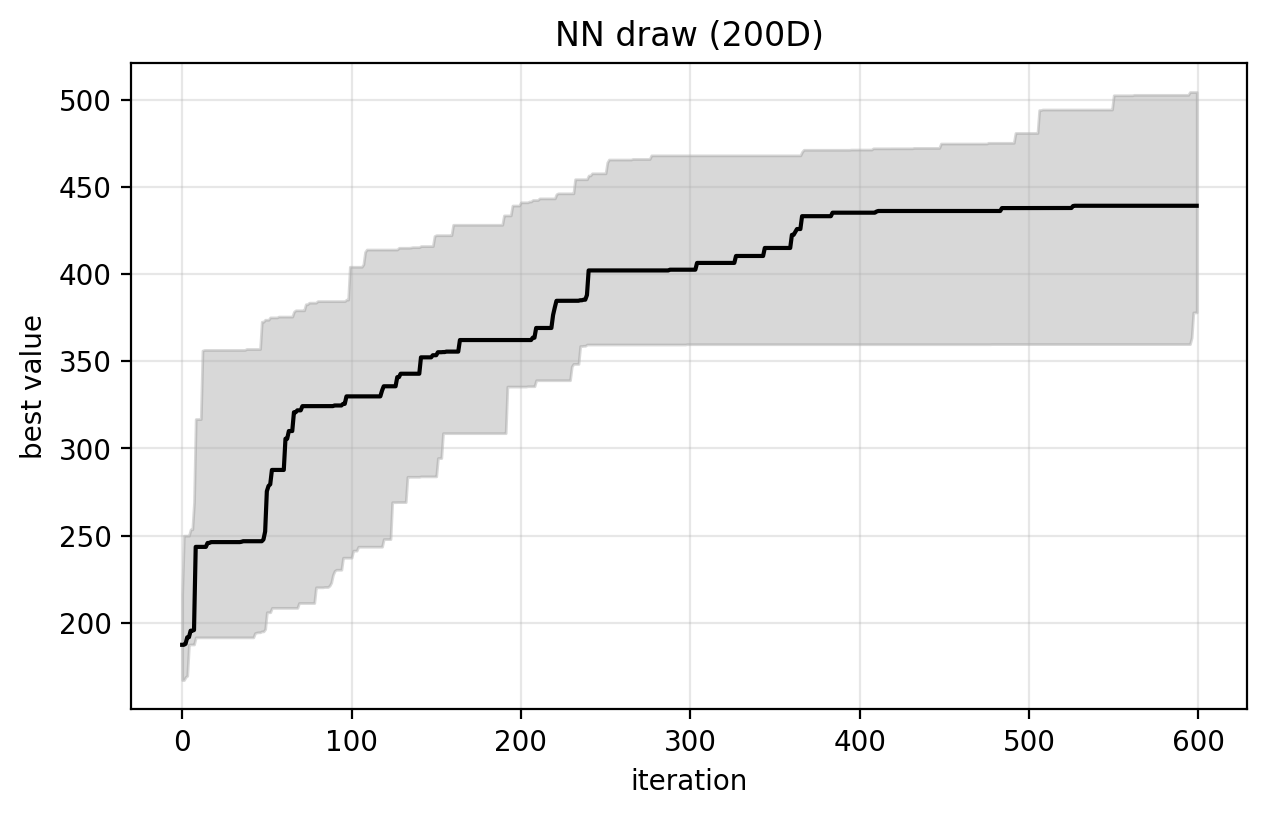

In [28]:
fig, ax = plt.subplots()
plot_hist(ax, runs_lofi["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

# Comparison

In [29]:
colors = sns.color_palette("colorblind", n_colors=6)
colors

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451)]

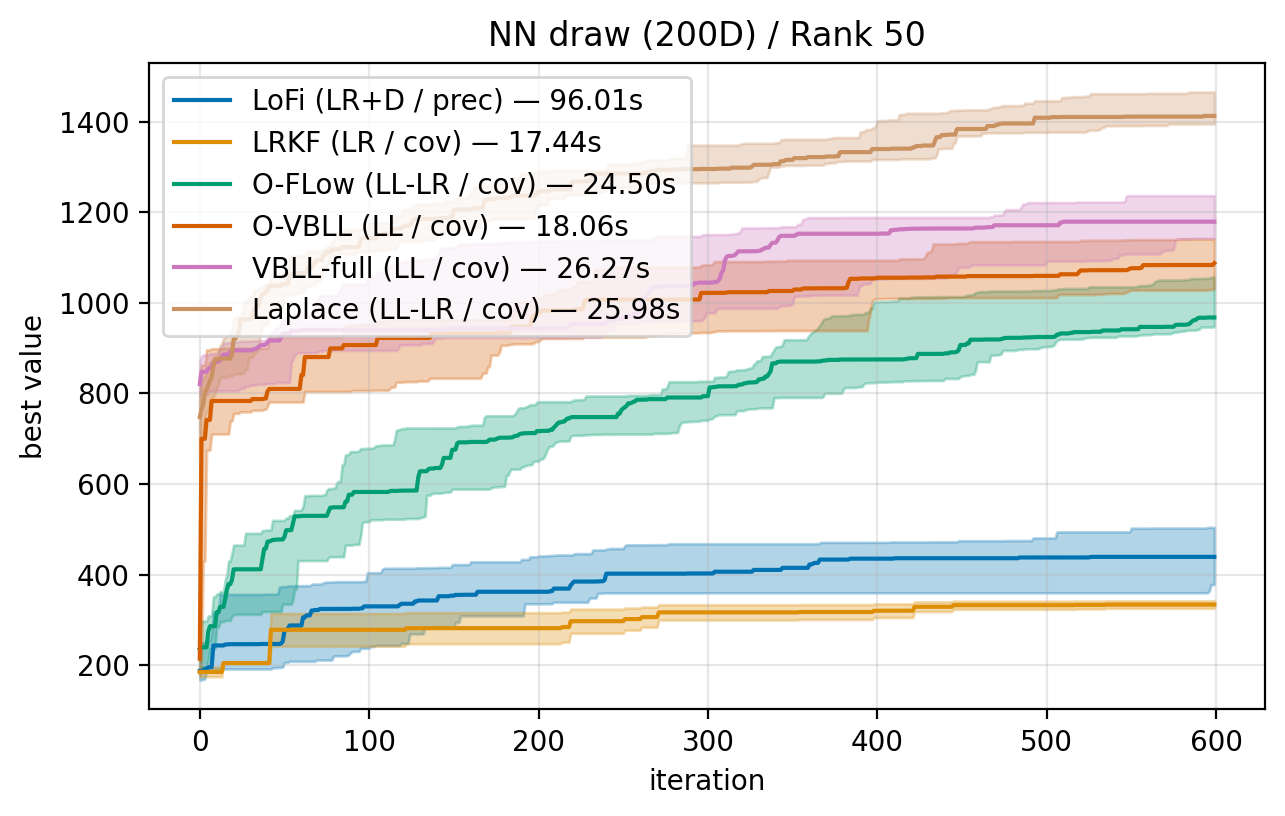

In [30]:
fig, ax = plt.subplots()
plot_hist(ax, runs_lofi["y_best"], label=f"LoFi (LR+D / prec) — {time_lofi:0.2f}s", color=colors[0])
plot_hist(ax, runs_lrkf["y_best"], label=f"LRKF (LR / cov) — {time_lrkf:0.2f}s",  color=colors[1])
plot_hist(ax, runs_flores["y_best"], label=f"O-FLow (LL-LR / cov) — {time_flores:0.2f}s",  color=colors[2])
plot_hist(ax, runs_vbll["y_best"], label=f"O-VBLL (LL / cov) — {time_vbll:0.2f}s",  color=colors[3])
plot_hist(ax, runs_vbll_full["y_best"], label=f"VBLL-full (LL / cov) — {time_vbll_full:0.2f}s",  color=colors[4])
plot_hist(ax, runs_laplace_diag["y_best"], label=f"Laplace (LL-LR / cov) — {time_laplace:0.2f}s",  color=colors[5])
# plot_hist(ax, runs_eflores["y_best"], label=f"en-O-FLow (LL-LR / cov) — {time_eflores:0.2f}s",  color=colors[5])
plt.title(f"NN draw ({dim}D) / Rank {rank}")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.legend()
plt.grid(alpha=0.3)
# plt.savefig(f"../figures/nn-draw-res-{dim}.png", dpi=300, bbox_inches="tight")

In [31]:
runs = {
    "VBLL-greedy": {**runs_vbll, "time": time_vbll},
    "VBLL": {**runs_vbll_full, "time": time_vbll_full},
    "FLoRES": {**runs_flores, "time": time_flores},
    "LRKF": {**runs_lrkf, "time": time_lrkf},
    "LOFI": {**runs_lofi, "time": time_lofi},
    "laplace": {**runs_laplace_diag, "time": time_laplace}
}

runs = jax.tree.map(np.array, runs)

In [32]:
import pickle
fn_string = f"nndraw{dim}"
with open(f"{fn_string}_{exploration_method}.pkl", "wb") as f:
    pickle.dump(runs, f)

## Run multiple dims

In [93]:
%%time
# ranks = [1, 10, 20, 50, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
ranks = [1, 10, 50, 100, 150, 200]
n_steps = 600
n_runs = 20
lbound, ubound = 0.0, 1.0
keys = jax.random.split(key_run, n_runs)

runs_all = {}
times_all = {}
for rank in ranks:
    print(rank, end="\r")

    time_init = time()
    # agent, bel_init_fn = agents.load_ll_lrkf_agent(
    #     X_init, rank=rank, cov_hidden=0.1, cov_last=1.0, dynamics_last=1e-6, dynamics_hidden=1e-6,
    # )
    agent, bel_init_fn = agents.load_ll_lrkf_agent(
        X_init, rank=rank, cov_hidden=0.1, cov_last=2.0, dynamics_last=1e-6, dynamics_hidden=0.0,
    )
    
    runs = eval_fn.test_runs(
        keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim, query_method, exploration_method
    )
    runs = jax.tree.map(np.array, runs)
    
    runs_all[rank] = runs
    times_all[rank] = time() - time_init

CPU times: user 3min 49s, sys: 3.57 s, total: 3min 52s
Wall time: 3min 44s


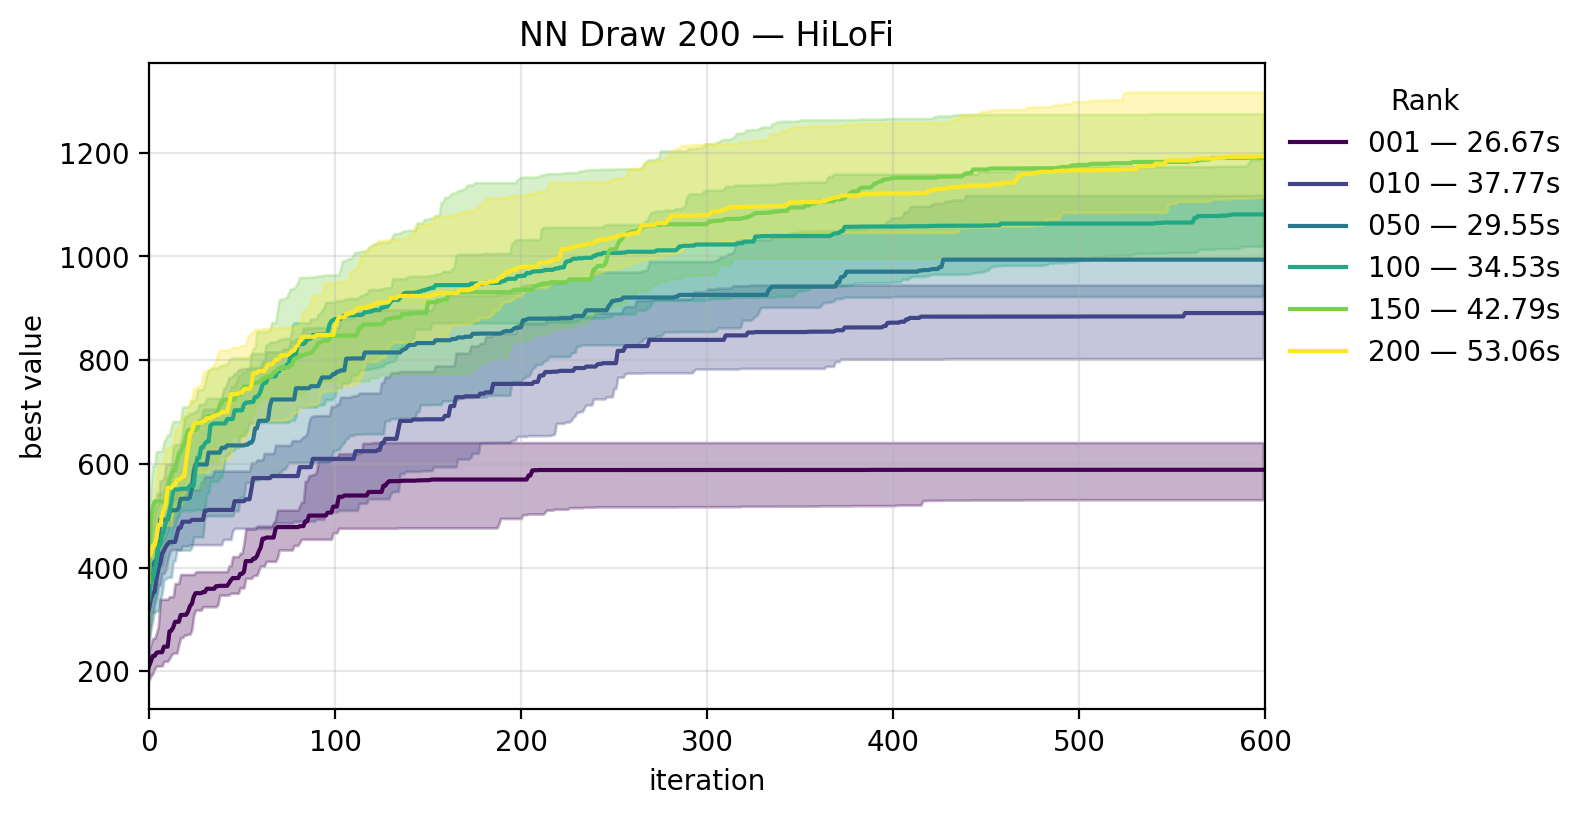

In [95]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

colors = plt.cm.viridis(np.linspace(0, 1, len(ranks)))
for color, rank in zip(colors, ranks):
    seconds = times_all[rank]
    label = f"{rank:03} — {seconds:0.2f}s"
    plot_hist(ax, runs_all[rank]["y_best"], color=color, label=label)
# plt.legend(title="Rank", ncols=2)
plt.legend(title="Rank", ncols=1, bbox_to_anchor=(1,1), frameon=False)
# plt.ylim(bottom=800)
plt.xlim(left=0.0, right=n_steps)
plt.title(f"NN Draw {dim} — HiLoFi")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
ymin, ymax = plt.ylim()
plt.savefig(f"../figures/nn-draw-hilofi-varying-dim.png", dpi=300, bbox_inches="tight")

In [87]:
summary_ranks = []

for rank in ranks:
    ybest_final = runs_all[rank]["y_best"][:, -1].mean()
    summary_ranks.append({
        "rank": rank,
        "time": times_all[rank],
        "ybest_final": ybest_final
    })

    rstr = f"{rank=:03} | {ybest_final:0.2f}"
    print(rstr)

summary_ranks = pd.DataFrame(summary_ranks)

rank=001 | 599.27
rank=010 | 887.08
rank=050 | 1025.94
rank=100 | 1092.09
rank=150 | 1134.98
rank=200 | 1190.62


In [88]:
print(summary_ranks.set_index("rank").to_markdown())

|   rank |    time |   ybest_final |
|-------:|--------:|--------------:|
|      1 | 26.4769 |       599.269 |
|     10 | 37.6071 |       887.079 |
|     50 | 30.1172 |      1025.94  |
|    100 | 35.4829 |      1092.09  |
|    150 | 42.881  |      1134.98  |
|    200 | 53.4165 |      1190.62  |


## LRKF 

In [89]:
%%time
ranks = [1, 10, 50, 100, 150, 200]

n_steps = 600
n_runs = 10
lbound, ubound = 0.0, 1.0
keys = jax.random.split(key_run, n_runs)

runs_all = {}
times_all = {}

for rank in ranks:
    print(rank, end="\r")
    agent, bel_init_fn = agents.load_lrkf_agent(
        X_init, rank=rank, cov=2.0, obs_noise=0.0, dynamics_cov=1.0, low_rank_diag=False,
    )
    time_init = time()
    
    runs_lrkf = eval_fn.test_runs(
        keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim, query_method, exploration_method
    )
    runs_lrkf = jax.tree.map(np.array, runs_lrkf)
    time_lrkf = time() - time_init
    
    runs_all[rank] = runs_lrkf
    times_all[rank] = time_lrkf

CPU times: user 2min 17s, sys: 2.65 s, total: 2min 20s
Wall time: 2min 18s


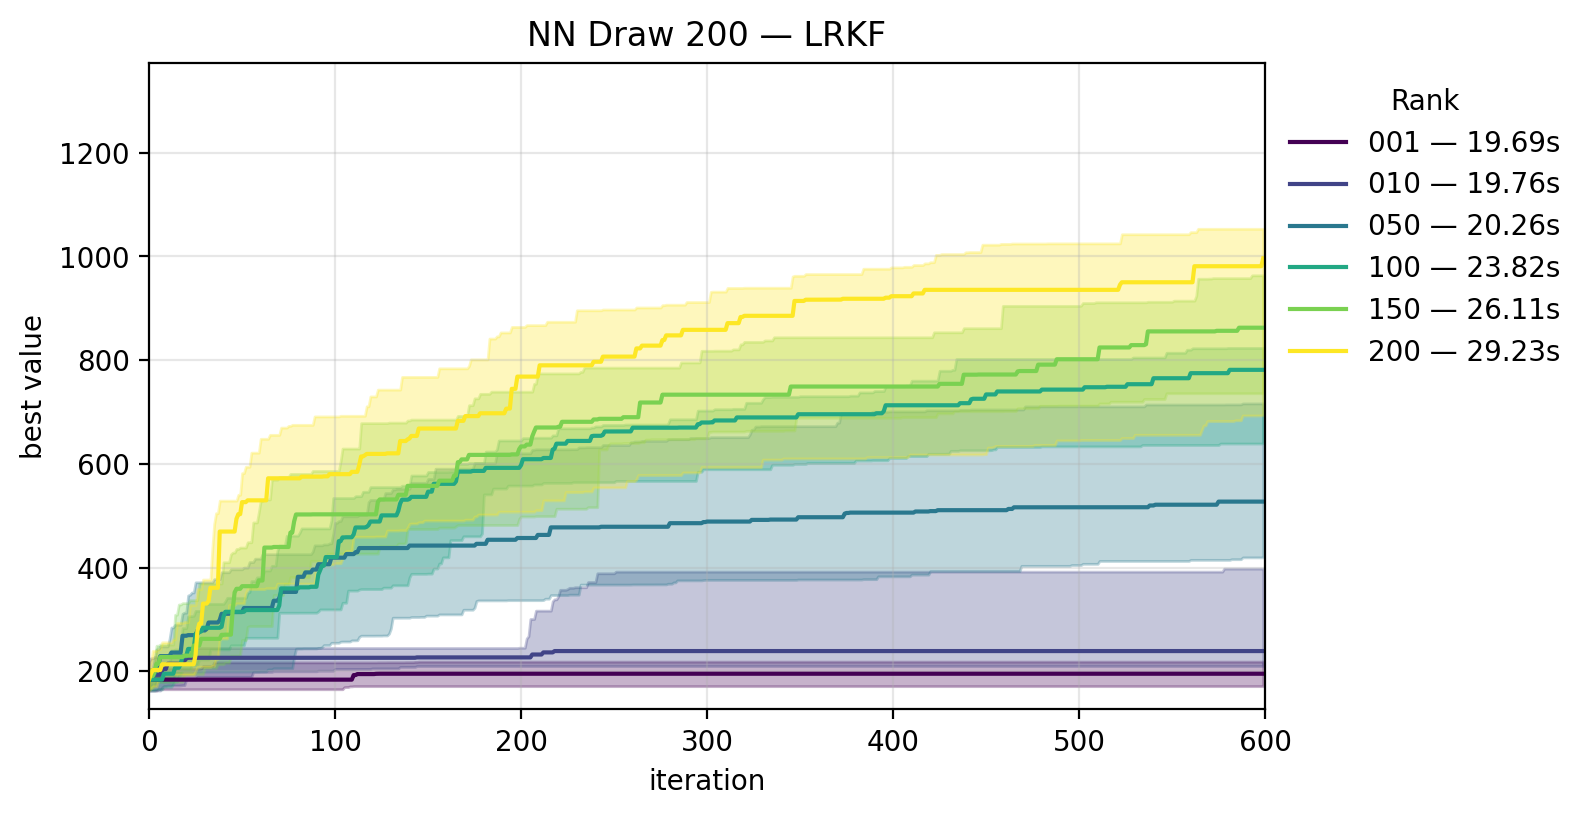

In [92]:
fig, ax = plt.subplots()

colors = plt.cm.viridis(np.linspace(0, 1, len(ranks)))
for color, rank, in zip(colors, ranks):
    seconds = times_all[rank]
    label = f"{rank:03} — {seconds:0.2f}s"
    plot_hist(ax, runs_all[rank]["y_best"], color=color, label=label)
# plot_hist(ax, runs_lofi["y_best"], label=f"LoFi(50) — {time_lofi:0.2f}s", color="black")
plt.legend(title="Rank", ncols=1, bbox_to_anchor=(1,1), frameon=False)
# plt.ylim(bottom=800)
plt.xlim(left=0.0, right=n_steps)
plt.title(f"NN Draw {dim} — LRKF")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
plt.ylim(ymin, ymax)
plt.savefig("../figures/nndraw200-lrkf.png", dpi=300, bbox_inches="tight")

## Run multiple choices of dynamic's covariance

In [51]:
from tqdm import tqdm
from itertools import product

In [53]:
%%time
rank = 100
n_steps = 600
n_runs = 20
dynamics = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
lbound, ubound = 0.0, 1.0
keys = jax.random.split(key_run, n_runs)

runs_all = {}
times_all = {}
elements = list(product(dynamics, dynamics))
for dh, dl in (pbar := tqdm(elements)):
    desc = f"{dh:0.0e} | {dl:0.0e}"
    pbar.set_description(desc)
    
    time_init = time()
    agent, bel_init_fn = agents.load_ll_lrkf_agent(
        X_init, rank=rank, cov_hidden=1.0, cov_last=1.0, dynamics_last=dl, dynamics_hidden=dh,
    )
    
    runs = eval_fn.test_runs(
        keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim, query_method, exploration_method
    )
    runs = jax.tree.map(np.array, runs)
    
    runs_all[(dh, dl)] = runs
    times_all[(dh, dl)] = time() - time_init

1e-03 | 1e-03: 100%|██████████████████████████████████████████████████████████████████████████████████████| 25/25 [13:48<00:00, 33.14s/it]

CPU times: user 17min 10s, sys: 20.2 s, total: 17min 31s
Wall time: 13min 48s


In [54]:
import pandas as pd

In [55]:
summary = []

for config in elements:
    dh, dl = config
    ybest_final = runs_all[config]["y_best"][:, -1].mean()
    summary.append({
        "qh": dh,
        "ql": dl,
        "ybest_final": ybest_final
    })

    rstr = f"{dh=:0.0e} | {dl=:0.0e} | {ybest_final:0.2f}"
    print(rstr)

summary = pd.DataFrame(summary)

dh=0e+00 | dl=0e+00 | 911.02
dh=0e+00 | dl=1e-06 | 925.54
dh=0e+00 | dl=1e-05 | 903.86
dh=0e+00 | dl=1e-04 | 856.53
dh=0e+00 | dl=1e-03 | 850.67
dh=1e-06 | dl=0e+00 | 908.95
dh=1e-06 | dl=1e-06 | 877.04
dh=1e-06 | dl=1e-05 | 902.75
dh=1e-06 | dl=1e-04 | 906.04
dh=1e-06 | dl=1e-03 | 915.50
dh=1e-05 | dl=0e+00 | 885.91
dh=1e-05 | dl=1e-06 | 858.06
dh=1e-05 | dl=1e-05 | 902.75
dh=1e-05 | dl=1e-04 | 883.26
dh=1e-05 | dl=1e-03 | 882.13
dh=1e-04 | dl=0e+00 | 880.66
dh=1e-04 | dl=1e-06 | 905.34
dh=1e-04 | dl=1e-05 | 877.90
dh=1e-04 | dl=1e-04 | 861.02
dh=1e-04 | dl=1e-03 | 895.53
dh=1e-03 | dl=0e+00 | 834.45
dh=1e-03 | dl=1e-06 | 791.29
dh=1e-03 | dl=1e-05 | 823.19
dh=1e-03 | dl=1e-04 | 809.96
dh=1e-03 | dl=1e-03 | 809.10


In [66]:
print(summary.pivot_table(index="qh", columns="ql", values="ybest_final").to_markdown())

|     qh |     0.0 |   1e-06 |   1e-05 |   0.0001 |   0.001 |
|-------:|--------:|--------:|--------:|---------:|--------:|
| 0      | 911.023 | 925.541 | 903.86  |  856.529 | 850.668 |
| 1e-06  | 908.951 | 877.041 | 902.752 |  906.037 | 915.497 |
| 1e-05  | 885.912 | 858.062 | 902.754 |  883.262 | 882.13  |
| 0.0001 | 880.655 | 905.342 | 877.899 |  861.019 | 895.526 |
| 0.001  | 834.449 | 791.294 | 823.188 |  809.964 | 809.104 |


/tmp/ipykernel_1867895/875401188.py:11: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(med_run, c=color_plot, **kwargs)


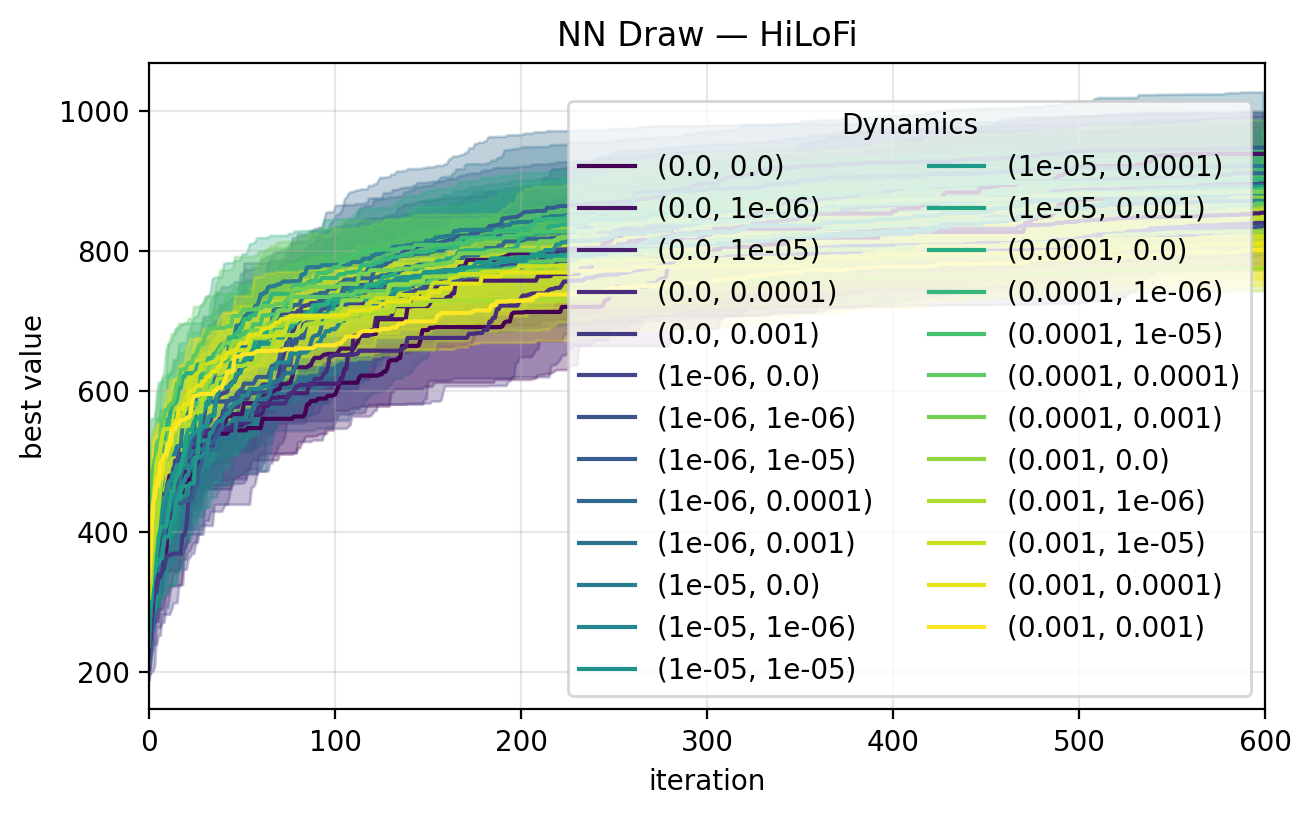

In [59]:
fig, ax = plt.subplots()

colors = plt.cm.viridis(np.linspace(0, 1, len(elements)))
for color, config in zip(colors, elements):
    plot_hist(ax, runs_all[config]["y_best"], color=color, label=config)
plt.legend(title="Dynamics", ncols=2)
# plt.ylim(bottom=800)
plt.xlim(left=0.0, right=n_steps)
plt.title("NN Draw — HiLoFi")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)

## Run multiple noise terms

In [ ]:
%%time
# obs_noise = [0.0, 1e-7, 5e-7, 1e-6]
obs_noise = [0.0, 1e-6]
rank = 20
n_steps = 600
n_runs = 20
lbound, ubound = 0.0, 1.0
keys = jax.random.split(key_run, n_runs)

runs_all = {}
for cfg in obs_noise:
    print(cfg, end="\r")
    
    agent, bel_init_fn = agents.load_ll_lrkf_agent(
        X_init, rank=rank, cov_hidden=1e-1, cov_last=0.1, obs_noise=cfg
    )    

    runs = eval_fn.test_runs(keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim, query_method)
    runs = jax.tree.map(np.array, runs)
    runs_all[cfg] = runs

In [ ]:
fig, ax = plt.subplots()

colors = plt.cm.viridis(np.linspace(0, 1, len(obs_noise)))
for color, cfg in zip(colors, obs_noise):
    plot_hist(ax, runs_all[cfg]["y_best"], color=color, label=cfg)
plt.legend(title="Rank", ncols=2)
plt.xlim(left=0.0, right=n_steps)
plt.title("NN Draw — LL-LRKF")
plt.grid(alpha=0.3)

## LoFi - no dynamics / low rank only

In [ ]:
rank = 50
agent, bel_init_fn = agents.load_lofi_agent(
    X_init, rank=rank, cov_init=1e-7, obs_noise=1.0, dynamics_covariance=0.0
)

In [ ]:
%%time
n_steps = 600
lbound, ubound = 0.0, 1.0
keys = jax.random.split(key_run, n_runs)
bel, runs_lrkf = eval_fn.test_run(
    key, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim
)
runs_lrkf = jax.tree.map(np.array, runs_lrkf)

In [ ]:
fig, ax = plt.subplots()
ax.plot(runs_lrkf["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

In [ ]:
%%time
time_init = time()
n_steps = 600
n_runs = 10
lbound, ubound = 0.0, 1.0
keys = jax.random.split(key_run, n_runs)
runs_lofi_null = eval_fn.test_runs(keys, n_steps, agent, bel_init_fn, objective_fn, dim, lbound, ubound, dim)
runs_lofi_null = jax.tree.map(np.array, runs_lofi_null)
time_lofi_null = time() - time_init

In [ ]:
fig, ax = plt.subplots()
plot_hist(ax, runs_lofi_null["y_best"])
plt.title(f"NN draw ({dim}D)")
plt.ylabel("best value")
plt.xlabel("iteration")
plt.grid(alpha=0.3)
# plt.xticks(np.arange(0, 110, 10));

* LRKF sucks but its fast
* LoFi works much better, but it's slow
* LL-LRKF has comparable speed to LRKF, but its the top performing method